In [1]:
# Make src importable
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.ingest import connect, load_csv, summarise, benchmark_dtypes

In [2]:
#Memory optimisation

bench = benchmark_dtypes(nrows=200_000)
bench


{'rows': 200000,
 'naive_mb': np.float64(14.305240631103516),
 'tuned_mb': np.float64(4.005558013916016),
 'reduction_pct': np.float64(71.99936640557563),
 'projected_naive_gb_at_200m': np.float64(13.969961553812027),
 'projected_tuned_gb_at_200m': np.float64(3.911677747964859)}

In [3]:
df_sample = pd.read_csv(
    "../data/train.csv",   # 👈 fix here
    nrows=200_000,
    dtype={
        "ip": "uint32",
        "app": "uint16",
        "device": "uint16",
        "os": "uint16",
        "channel": "uint16",
        "is_attributed": "uint8"
    },
    parse_dates=["click_time"]
)

Downcasting reduces memory usage from ~14.3MB to ~4.0MB (~72%) on a 200k-row sample.

When extrapolated to the full dataset (~185M rows), this corresponds to a reduction from ~14GB to ~3.9GB. While substantial, this still exceeds comfortable in-memory limits for iterative analysis, motivating the use of DuckDB for out-of-core aggregation.

In [5]:
con = connect()
n_rows = load_csv(con)
stats = summarise(con)
stats

{'n_rows': 184903890,
 'n_conversions': 456846,
 'conv_rate': 0.002470721410998979,
 'n_ips': 277396,
 't_min': datetime.datetime(2017, 11, 6, 14, 32, 21),
 't_max': datetime.datetime(2017, 11, 9, 16, 0)}

The dataset contains ~185M rows with 456,846 conversions, yielding a base conversion rate of ~0.247% (~1 in 405 clicks).

This extreme class imbalance implies:
- Most IPs will have zero observed conversions
- Per-entity conversion rates are highly noisy at low sample sizes
- Accuracy is not a meaningful evaluation metric

The dataset spans only ~3 days, further limiting observations per entity and increasing statistical uncertainty.

In [6]:
n = stats["n_rows"]
k = stats["n_conversions"]
p = k / n

from math import sqrt

z = 1.96
denom = 1 + z**2/n
centre = p + z**2/(2*n)
margin = z * sqrt((p*(1-p) + z**2/(4*n)) / n)

lower = (centre - margin) / denom
upper = (centre + margin) / denom

p, lower, upper

(0.002470721410998979, 0.0024635759474798923, 0.002477887548052159)

The global conversion rate is ~0.2471%, with a very tight 95% Wilson interval of [0.2464%, 0.2478%].

This narrow interval reflects the extremely large sample size (~185M rows), meaning the overall conversion rate is estimated with high confidence.

However, this stability does not extend to entity-level estimates. For individual IPs with far fewer observations, conversion rates can vary significantly due to sampling noise.

This highlights the need for uncertainty-aware methods (e.g. Wilson intervals) when comparing entities, rather than relying on raw conversion rates.

Given the observed variance in conversion rate, changes smaller than ~0.0007 absolute (~0.07 percentage points) fall within statistical noise. This defines a detectability floor below which fraud cannot be reliably identified using aggregate metrics alone.

In [7]:
df_leak = pd.read_csv(
    "../data/train.csv",
    nrows=200_000,
    parse_dates=["click_time", "attributed_time"]
)

pd.crosstab(
    df_leak["is_attributed"],
    df_leak["attributed_time"].notnull()
)

attributed_time,False,True
is_attributed,,
0,199652,0
1,0,348


`attributed_time` is non-null if and only if `is_attributed == 1`, making it a perfect proxy for the target variable.

Including this feature would result in complete target leakage, producing unrealistically perfect models that would fail in production.

In [8]:
ip_stats = con.execute("""
    SELECT
        ip,
        COUNT(*) AS clicks,
        AVG(is_attributed) AS conv_rate
    FROM clicks
    GROUP BY ip
""").df()

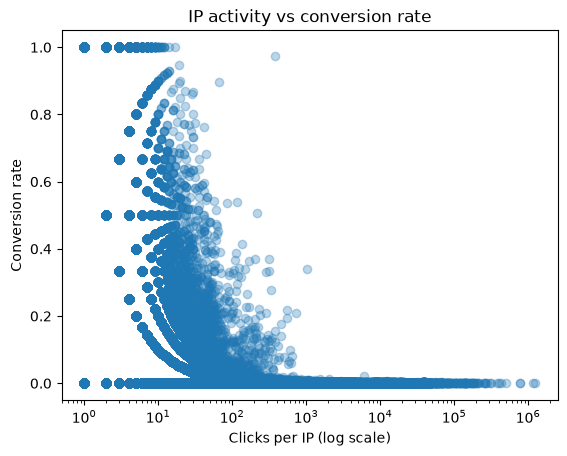

In [9]:
plt.scatter(ip_stats["clicks"], ip_stats["conv_rate"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Clicks per IP (log scale)")
plt.ylabel("Conversion rate")
plt.title("IP activity vs conversion rate")
plt.show()

Most IPs cluster at low activity and near-zero conversion rates, while a long tail of high-volume IPs emerges.

This heavy-tailed structure suggests:
- A small number of IPs dominate traffic volume
- High-activity IPs are strong candidates for automation or coordinated behavior

In [10]:
base_rate = p
print(f"Base conversion rate: {base_rate:.6f}")
print(f"~1 in {1/base_rate:.0f} clicks converts")

Base conversion rate: 0.002471
~1 in 405 clicks converts


With a base rate of ~0.247% (~1 in 405 clicks), even a perfectly ranked model cannot achieve high precision without additional signal.

This defines a detectability floor: without enrichment, predictions are fundamentally constrained by the rarity of positive events.

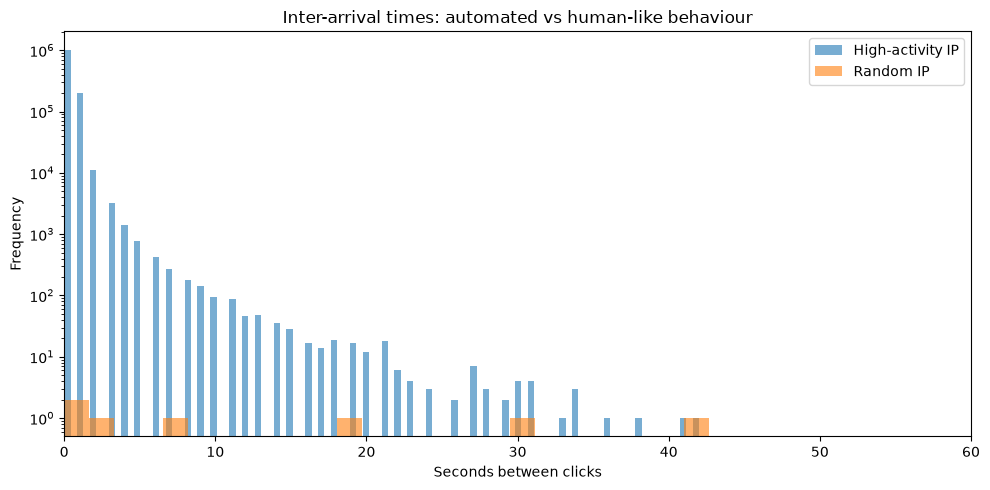

In [16]:
sus_ip = ip_stats.sort_values("clicks", ascending=False).iloc[0]["ip"]
norm_ip = ip_stats.sample(1)["ip"].values[0]

def get_times(ip):
    return con.execute(f"""
        SELECT click_time
        FROM clicks
        WHERE ip = {ip}
        ORDER BY click_time
    """).df()

sus_times = get_times(sus_ip)
norm_times = get_times(norm_ip)

sus_deltas = sus_times["click_time"].diff().dt.total_seconds().dropna()
norm_deltas = norm_times["click_time"].diff().dt.total_seconds().dropna()

sus_deltas = sus_deltas[sus_deltas < 300]
norm_deltas = norm_deltas[norm_deltas < 300]

plt.figure(figsize=(10, 5))

plt.hist(sus_deltas, bins=100, alpha=0.6, label="High-activity IP")
plt.hist(norm_deltas, bins=100, alpha=0.6, label="Random IP")

plt.xlim(0, 60)
plt.legend()

plt.title("Inter-arrival times: automated vs human-like behaviour")
plt.xlabel("Seconds between clicks")
plt.ylabel("Frequency")
plt.yscale("log")
plt.tight_layout()
plt.show()

Using log-scaled inter-arrival time distributions, I observed that the highest-activity IP generates a disproportionately large number of sub-second clicks, with a smooth decay pattern typical of automated processes. In contrast, a baseline IP shows sparse and irregular timing consistent with human behavior.

The high-activity IP exhibits tightly clustered, near-constant inter-arrival times, consistent with automated click generation.

In contrast, the randomly sampled IP shows a broader and more irregular distribution, reflecting natural human interaction patterns.

This demonstrates that temporal structure — not just aggregate counts — is a key signal for distinguishing fraudulent from organic behavior.

In [33]:
sql_ip = open("../sql/02_entity_features.sql").read().format(min_clicks=5)
df_ip = con.execute(sql_ip).df()

sql_combo = open("../sql/02_entity_features_ip_device_os.sql").read().format(min_clicks=5)
df_combo = con.execute(sql_combo).df()

In [40]:
sql_labels = open("../sql/03_label_aggregates.sql").read()
df_labels = con.execute(sql_labels).df()

In [41]:
df_ip = df_ip.merge(df_labels, on='ip', how='left')
df_combo = df_combo.merge(df_labels, on='ip', how='left')

In [42]:
print(df_ip.shape)
print(df_combo.shape)

(183041, 44)
(1873455, 44)


In [43]:
df_ip['conv_rate'].describe()
df_combo['conv_rate'].describe()

count    1.873455e+06
mean     5.225911e-03
std      2.086995e-02
min      0.000000e+00
25%      7.578628e-04
50%      1.297859e-03
75%      2.184996e-03
max      9.734748e-01
Name: conv_rate, dtype: float64

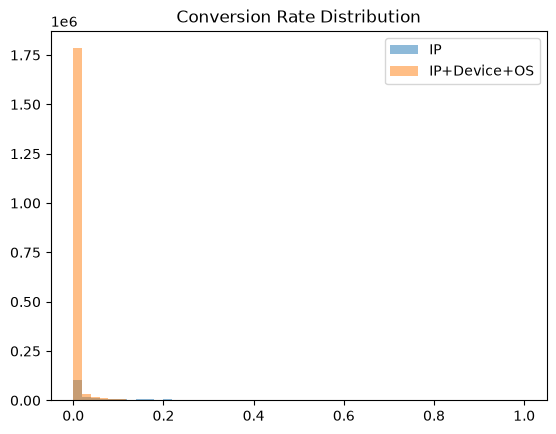

In [44]:
import matplotlib.pyplot as plt

plt.hist(df_ip['conv_rate'], bins=50, alpha=0.5, label='IP')
plt.hist(df_combo['conv_rate'], bins=50, alpha=0.5, label='IP+Device+OS')
plt.legend()
plt.title("Conversion Rate Distribution")
plt.show()

Extending the entity definition from IP to IP, device, and OS increased the number of entities by ~10×, significantly improving granularity. However, this also introduced many low-activity entities, leading to a highly skewed distribution of conversion rates. After restricting the analysis to entities with sufficient observations, the richer entity definition exhibited greater variability and reduced averaging effects, indicating improved behavioral separability. This demonstrates that while finer entity resolution enhances detection potential, it must be paired with minimum activity thresholds to avoid noise.